### Data Analysis for Open-Ended Pathology VQA

This code will perform the anaylysis for the data collected by the Pathologists

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

Reading the data

In [2]:
vqa_data = pd.read_csv('data/path_open_vqa.csv')
vqa_data = vqa_data.rename(columns={vqa_data.columns[2]: 'Image1_Path',
                                    vqa_data.columns[26]: 'Image2_Path',
                                    vqa_data.columns[27]: 'Image3_Path',
                                    vqa_data.columns[28]: 'Image4_Path',
                                    vqa_data.columns[29]: 'Image5_Path',
                                    'Image 1 Magnification ': 'Image1_Mag',
                                    'Image 2 Magnification ': 'Image2_Mag',
                                    'Image 3 Magnification ': 'Image3_Mag',
                                    'Image 4 Magnification ': 'Image4_Mag',
                                    'Image 5 Magnification ': 'Image5_Mag'})
vqa_data.head()

,Timestamp,Pathologist ID,Image1_Path,Organ,Categorization,Regional Anatomy,Open Ended - Question 1,Open Ended - Answer 1,Open Ended - Answer 2,Open Ended - Question 2,...,Open Ended - Wrong Answer 1,Open Ended - Wrong Answer 2,Image2_Mag,Image3_Mag,Image4_Mag,Image5_Mag,Image2_Path,Image3_Path,Image4_Path,Image5_Path
0,2/25/2025 13:41:20,CK,https://drive.google.com/open?id=1tgv50Q9W4Bm_...,Hematolymphoid - Lymph Nodes,Neoplasia (Malignant),Lymph node,What is the primary architectural pattern obse...,Nodular pattern,Germinal centers are absent,What is a common component of lymph node archi...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2/25/2025 13:46:25,CK,https://drive.google.com/open?id=1igYpj4RL0XKx...,Hematolymphoid - Lymph Nodes,Neoplasia (Malignant),Lymph node,What is the predominant cell type seen here?,The main cell type observed here is a lymphocy...,These would best be characterized as small lym...,What is the best description for the cell size...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2/25/2025 13:51:37,CK,https://drive.google.com/open?id=1DKNZJQJ17SkX...,Hematolymphoid - Lymph Nodes,Neoplasia (Malignant),Lymph node,"In this mantle cell lymphoma, what is the best...",The nuclei of the abnormal lymphocytes are mos...,This should be considered a highly cellular ti...,What is the best description for the density a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2/26/2025 11:30:23,CK,https://drive.google.com/open?id=1jUe0z6wlZ0s9...,Gastrointestinal - Small Intenstine,Infection (Benign),Intestinal villous mucosa,"In a child with poor weight gain, what are the...",Features that argue against celiac disease in ...,Granulomas here are often the consequence of u...,What does the granuloma in the lamina propria ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2/26/2025 11:42:26,CK,https://drive.google.com/open?id=1VNr78I5w671g...,Gastrointestinal - Dudenum,Infection (Benign),Intestinal villous mucosa,What are the main histologic features of a non...,Non-necrotizing granulomas are characterized b...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Total Cases/Images

In [3]:
print("Total Cases:", len(vqa_data))
print("Total Images 1:", sum(~vqa_data['Image1_Path'].isnull()))
print("Total Images 2:", sum(~vqa_data['Image2_Path'].isnull()))
print("Total Images 3:", sum(~vqa_data['Image3_Path'].isnull()))
print("Total Images 4:", sum(~vqa_data['Image4_Path'].isnull()))
print("Total Images 5:", sum(~vqa_data['Image5_Path'].isnull()))

Total Cases: 157
Total Images 1: 157
Total Images 2: 37
Total Images 3: 37
Total Images 4: 0
Total Images 5: 0


#### Pathologist  Cases Breakdown

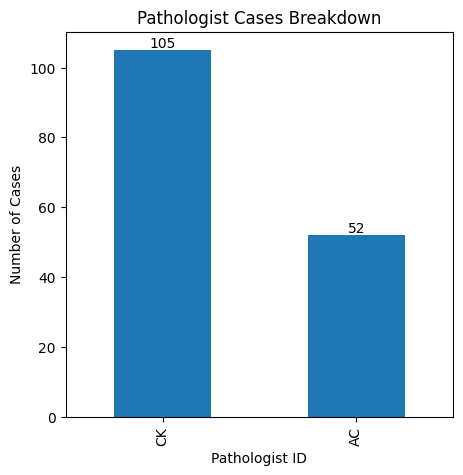

In [4]:
ax = vqa_data['Pathologist ID'].value_counts().plot(kind='bar', figsize=(5, 5), title='Pathologist Cases Breakdown', xlabel='Pathologist ID', ylabel='Number of Cases', label='Pathologist ID')
ax.bar_label(ax.containers[0])
plt.show()

#### Image Magnification Breakdown

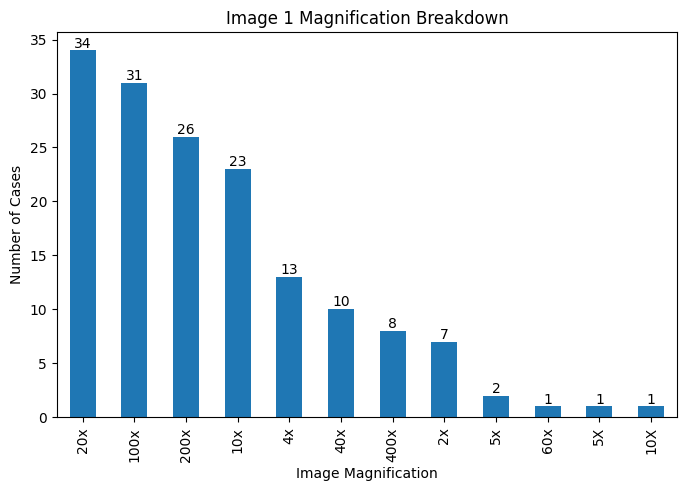

In [5]:
ax=vqa_data['Image1_Mag'].value_counts().plot(kind='bar', figsize=(8, 5), title='Image 1 Magnification Breakdown', xlabel='Image Magnification', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.show()

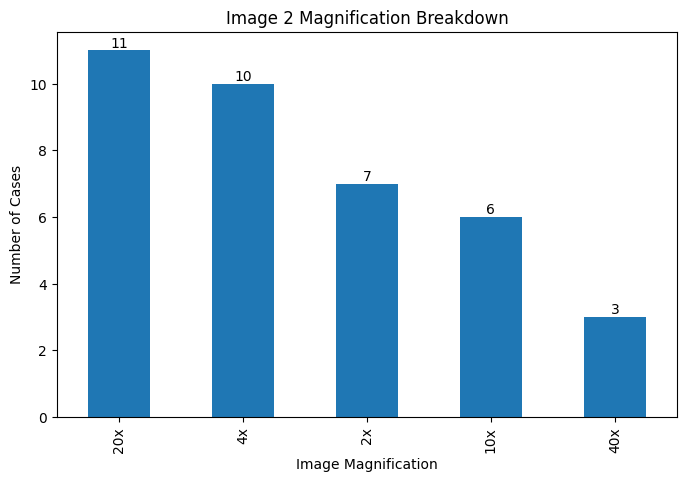

In [6]:
ax=vqa_data['Image2_Mag'].value_counts().plot(kind='bar', figsize=(8, 5), title='Image 2 Magnification Breakdown', xlabel='Image Magnification', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.show()

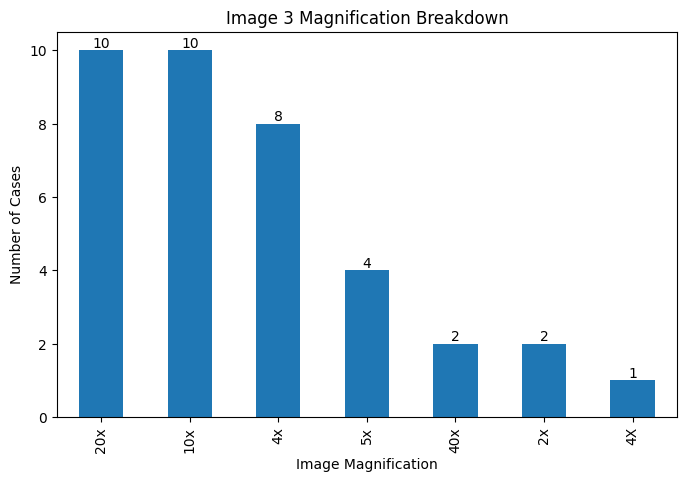

In [7]:
ax=vqa_data['Image3_Mag'].value_counts().plot(kind='bar', figsize=(8, 5), title='Image 3 Magnification Breakdown', xlabel='Image Magnification', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.show()

#### Organ Breakdown

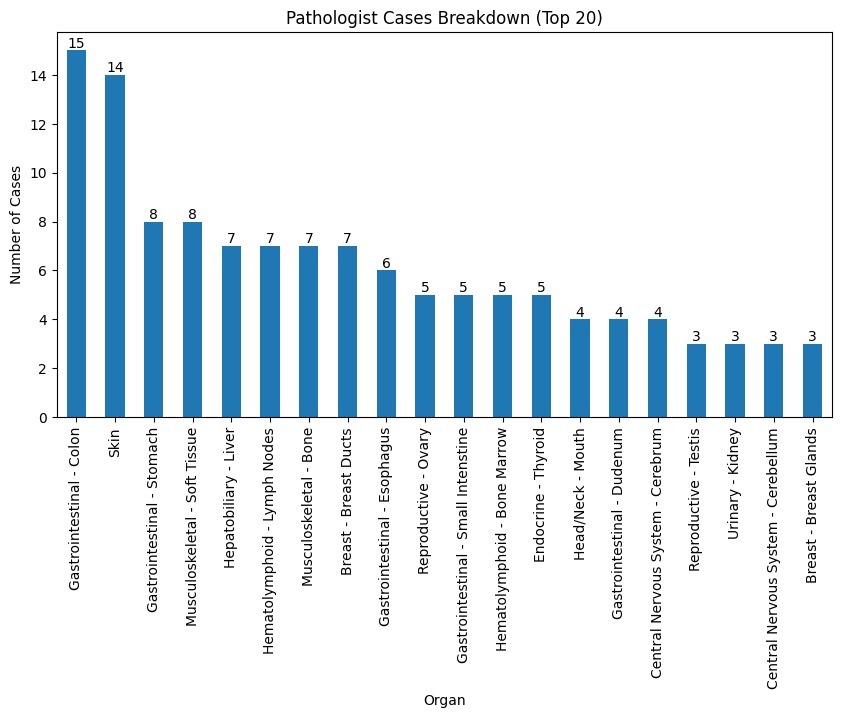

In [8]:
ax = vqa_data['Organ'].value_counts().head(20).plot(kind='bar', figsize=(10, 5), title='Pathologist Cases Breakdown (Top 20)', xlabel='Organ', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.show()

#### Categorization Breakdown

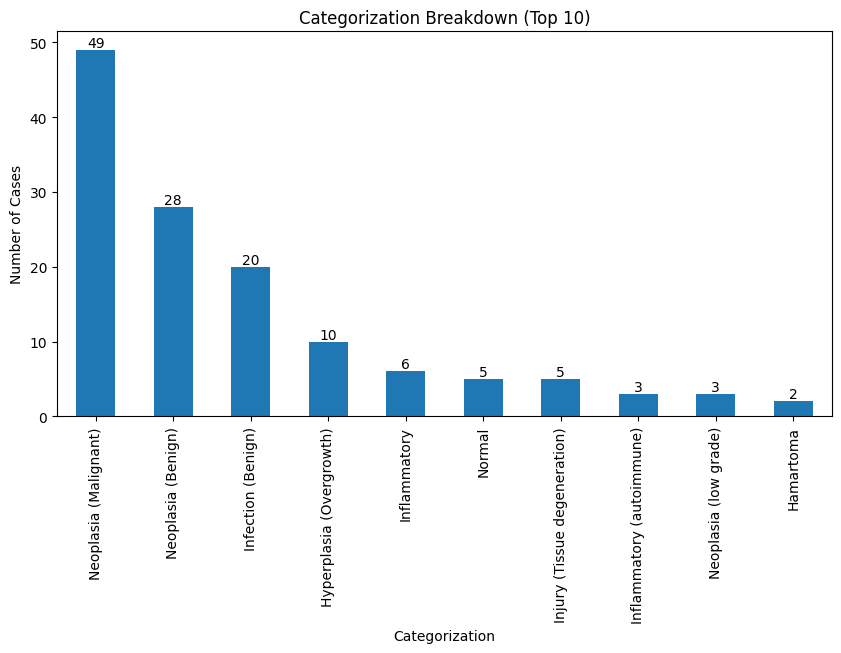

In [9]:
ax = vqa_data['Categorization'].value_counts().head(10).plot(kind='bar', figsize=(10, 5), title='Categorization Breakdown (Top 10)', xlabel='Categorization', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.show()

#### Regional Anatomy Breakdown

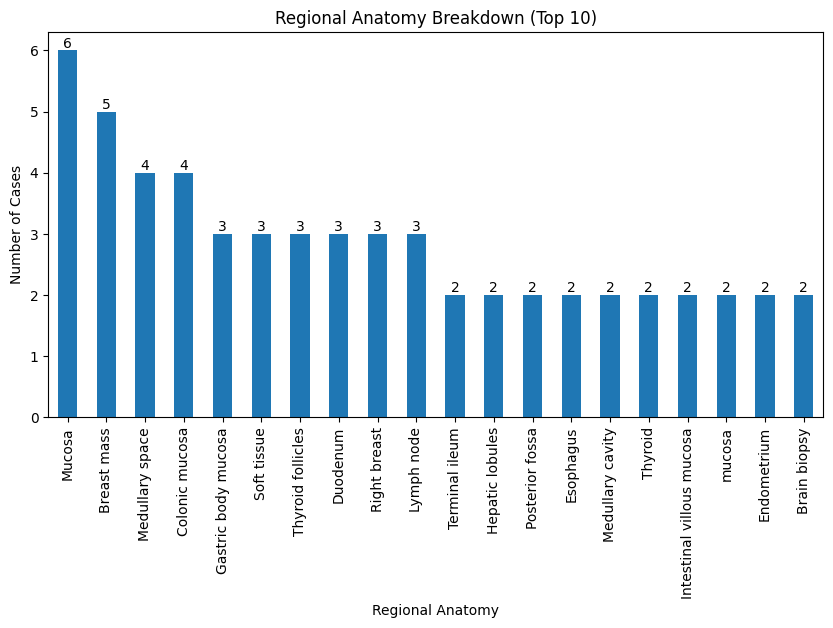

In [10]:
ax = vqa_data['Regional Anatomy'].value_counts().head(20).plot(kind='bar', figsize=(10, 5), title='Regional Anatomy Breakdown (Top 10)', xlabel='Regional Anatomy', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.show()

#### Open-Ended Questions/Answers

In [16]:
open_ended_1 = vqa_data[(~vqa_data['Open Ended - Question 1'].isnull()) & (~vqa_data['Open Ended - Answer 1'].isnull())]
open_ended_1_with_wrong = vqa_data[(~vqa_data['Open Ended - Question 1'].isnull()) & (~vqa_data['Open Ended - Answer 1'].isnull()) & (~vqa_data['Open Ended - Wrong Answer 1'].isnull())]
open_ended_1_without_wrong = vqa_data[(~vqa_data['Open Ended - Question 1'].isnull()) & (~vqa_data['Open Ended - Answer 1'].isnull()) & (vqa_data['Open Ended - Wrong Answer 1'].isnull())]

open_ended_2 = vqa_data[(~vqa_data['Open Ended - Question 2'].isnull()) & (~vqa_data['Open Ended - Answer 2'].isnull())]
open_ended_2_with_wrong = vqa_data[(~vqa_data['Open Ended - Question 2'].isnull()) & (~vqa_data['Open Ended - Answer 2'].isnull()) & (~vqa_data['Open Ended - Wrong Answer 2'].isnull())]
open_ended_2_without_wrong = vqa_data[(~vqa_data['Open Ended - Question 2'].isnull()) & (~vqa_data['Open Ended - Answer 2'].isnull()) & (vqa_data['Open Ended - Wrong Answer 2'].isnull())]

In [21]:
open_ended = pd.concat([open_ended_1, open_ended_2])
open_ended_with_wrong = pd.concat([open_ended_1_with_wrong, open_ended_2_with_wrong])
open_ended_without_wrong = pd.concat([open_ended_1_without_wrong, open_ended_2_without_wrong])

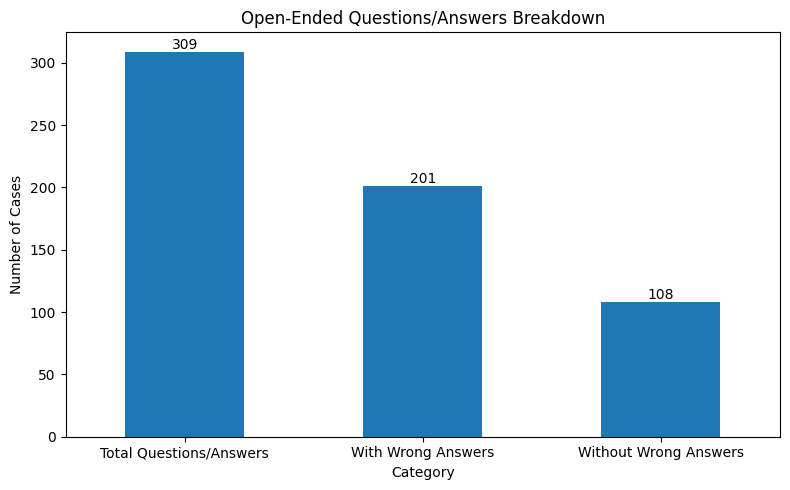

In [22]:
ax = pd.Series({
    'Total Questions/Answers': len(open_ended),
    'With Wrong Answers': len(open_ended_with_wrong),
    'Without Wrong Answers': len(open_ended_without_wrong)
}).plot(kind='bar', figsize=(8, 5), title='Open-Ended Questions/Answers Breakdown', xlabel='Category', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Extracting Word Distribution

In [58]:
open_ended_questions = list(open_ended['Open Ended - Question 1'].dropna().unique()) + list(open_ended['Open Ended - Question 2'].dropna().unique())
open_ended_correct_answers = list(open_ended['Open Ended - Answer 1'].dropna().unique()) + list(open_ended['Open Ended - Answer 2'].dropna().unique())
open_ended_wrong_answers = list(open_ended['Open Ended - Wrong Answer 1'].dropna().unique()) + list(open_ended['Open Ended - Wrong Answer 2'].dropna().unique())

valid_open_ended_questions = [sample for sample in open_ended_questions if len(sample.split()) >= 5]
valid_open_ended_correct_answers = [sample for sample in open_ended_correct_answers if len(sample.split()) >= 5]
valid_open_ended_wrong_answers = [sample for sample in open_ended_wrong_answers if len(sample.split()) >= 5]

print(f'Number of Valid Open-Ended Questions: {len(valid_open_ended_questions)}/{len(open_ended_questions)}')
print(f'Number of Valid Open-Ended Correct Answers: {len(valid_open_ended_correct_answers)}/{len(open_ended_correct_answers)}')
print(f'Number of Valid Open-Ended Wrong Answers: {len(valid_open_ended_wrong_answers)}/{len(open_ended_wrong_answers)}')

open_ended_questions_first_word = [sample.split()[0].lower() for sample in open_ended_questions]
counts = Counter(open_ended_questions_first_word)
print(f"First Word in Open-Ended Questions: ", counts)

Number of Valid Open-Ended Questions: 306/306
Number of Valid Open-Ended Correct Answers: 306/309
Number of Valid Open-Ended Wrong Answers: 201/201
First Word in Open-Ended Questions:  Counter({'what': 198, 'how': 29, 'considering': 23, 'in': 17, 'assuming': 10, 'the': 5, 'if': 4, 'this': 4, 'based': 4, 'given': 3, 'is': 2, 'describe': 1, 'why': 1, 'where': 1, 'does': 1, 'which': 1, 'for': 1, 'under': 1})


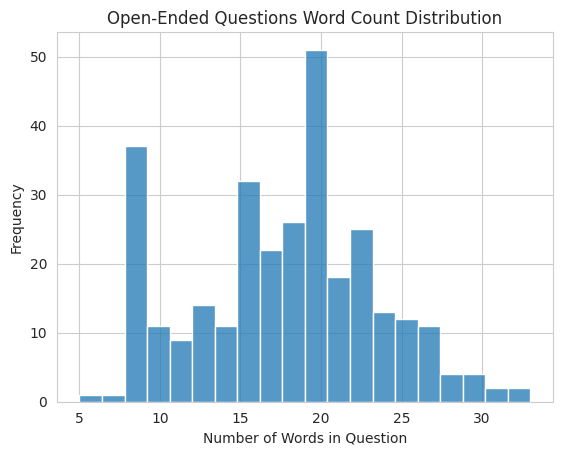

In [54]:
open_ended_questions_words_distrib = [len(sample.split()) for sample in open_ended_questions]
sns.set_style("whitegrid")
sns.histplot(open_ended_questions_words_distrib, bins=20)
plt.title(f'Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

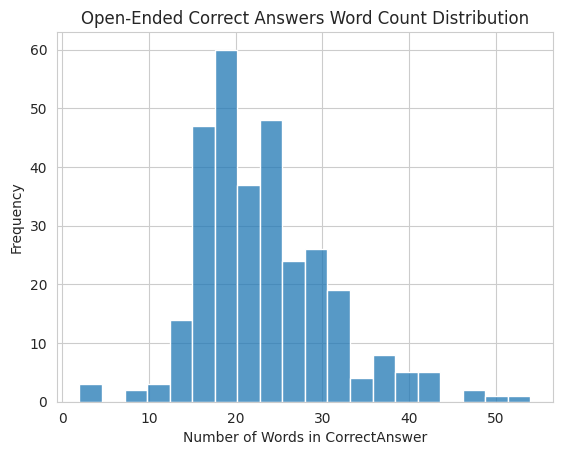

In [56]:
open_ended_correct_answers_words_distrib = [len(sample.split()) for sample in open_ended_correct_answers]
sns.set_style("whitegrid")
sns.histplot(open_ended_correct_answers_words_distrib, bins=20)
plt.title(f'Open-Ended Correct Answers Word Count Distribution')
plt.xlabel('Number of Words in CorrectAnswer')
plt.ylabel('Frequency')
plt.show()

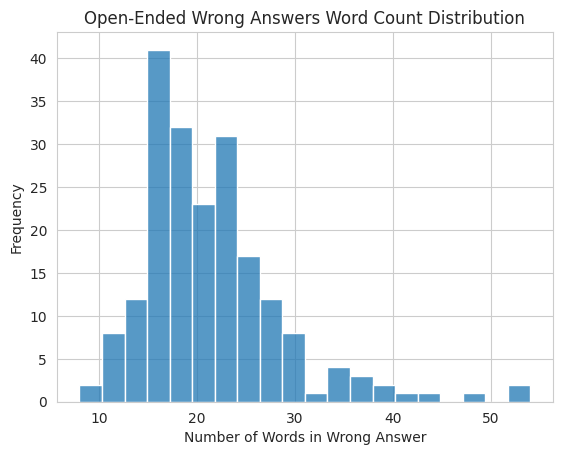

In [57]:
open_ended_wrong_answers_words_distrib = [len(sample.split()) for sample in open_ended_wrong_answers]
sns.set_style("whitegrid")
sns.histplot(open_ended_wrong_answers_words_distrib, bins=20)
plt.title(f'Open-Ended Wrong Answers Word Count Distribution')
plt.xlabel('Number of Words in Wrong Answer')
plt.ylabel('Frequency')
plt.show()

### Multiple Choice Questions/Answers

In [14]:
print("Total MCQ Questions/Answers: ", len(vqa_data[(~vqa_data['MCQ - Question'].isnull()) &
                                        (~vqa_data['MCQ - Option 1'].isnull()) &
                                        (~vqa_data['MCQ - Option 2'].isnull()) &
                                        (~vqa_data['MCQ - Option 3'].isnull()) &
                                        (~vqa_data['MCQ - Option 4'].isnull()) &
                                        (~vqa_data['MCQ - Option 5'].isnull()) &
                                        (~vqa_data['MCQ - Answer'].isnull())]))

Total MCQ Questions/Answers:  157


Extracting Words Distribution

In [60]:
mcq_questions = list(vqa_data['MCQ - Question'].dropna().unique())
mcq_options_1 = list(vqa_data['MCQ - Option 1'].dropna().unique())
mcq_options_2 = list(vqa_data['MCQ - Option 2'].dropna().unique())
mcq_options_3 = list(vqa_data['MCQ - Option 3'].dropna().unique())
mcq_options_4 = list(vqa_data['MCQ - Option 4'].dropna().unique())
mcq_options_5 = list(vqa_data['MCQ - Option 5'].dropna().unique())

valid_mcq_questions = [sample for sample in mcq_questions if len(sample.split()) >= 5]
valid_mcq_options_1 = [sample for sample in mcq_options_1 if len(sample.split()) >= 5]
valid_mcq_options_2 = [sample for sample in mcq_options_2 if len(sample.split()) >= 5]
valid_mcq_options_3 = [sample for sample in mcq_options_3 if len(sample.split()) >= 5]
valid_mcq_options_4 = [sample for sample in mcq_options_4 if len(sample.split()) >= 5]
valid_mcq_options_5 = [sample for sample in mcq_options_5 if len(sample.split()) >= 5]

print(f'Number of Valid MCQ Questions: {len(valid_mcq_questions)}/{len(mcq_questions)}')
print(f'Number of Valid MCQ Options 1: {len(valid_mcq_options_1)}/{len(mcq_options_1)}')
print(f'Number of Valid MCQ Options 2: {len(valid_mcq_options_2)}/{len(mcq_options_2)}')
print(f'Number of Valid MCQ Options 3: {len(valid_mcq_options_3)}/{len(mcq_options_3)}')
print(f'Number of Valid MCQ Options 4: {len(valid_mcq_options_4)}/{len(mcq_options_4)}')
print(f'Number of Valid MCQ Options 5: {len(valid_mcq_options_5)}/{len(mcq_options_5)}')

mcq_questions_first_word = [sample.split()[0].lower() for sample in mcq_questions]
counts = Counter(mcq_questions_first_word)
print(f"First Word in MCQ Questions: ", counts)

Number of Valid MCQ Questions: 155/155
Number of Valid MCQ Options 1: 102/155
Number of Valid MCQ Options 2: 101/154
Number of Valid MCQ Options 3: 99/156
Number of Valid MCQ Options 4: 104/156
Number of Valid MCQ Options 5: 100/154
First Word in MCQ Questions:  Counter({'what': 81, 'considering': 30, 'in': 8, 'assuming': 6, 'the': 5, 'which': 4, 'given': 4, 'if': 3, 'for': 2, 'based': 2, 'is': 2, 'how': 2, 'lymphocytes': 1, 'hyperkeratosis,': 1, 'all': 1, 'finding': 1, 'this': 1, 'a': 1})


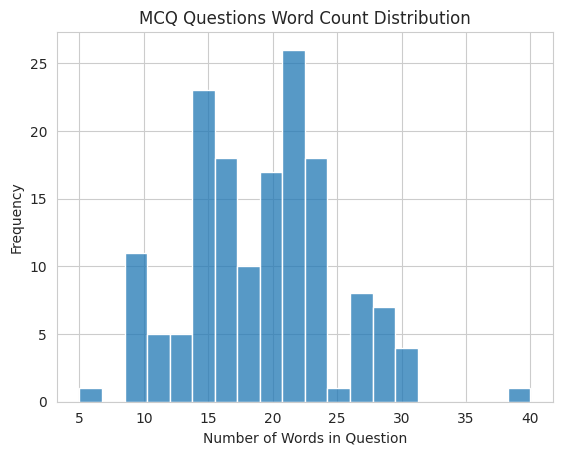

In [61]:
mcq_questions_words_distrib = [len(sample.split()) for sample in mcq_questions]
sns.set_style("whitegrid")
sns.histplot(mcq_questions_words_distrib, bins=20)
plt.title(f'MCQ Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

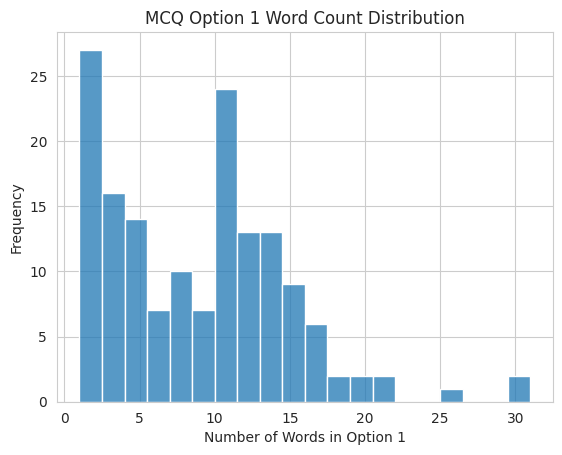

In [ ]:
mcq_option_1_words_distrib = [len(sample.split()) for sample in mcq_options_1]
sns.set_style("whitegrid")
sns.histplot(mcq_option_1_words_distrib, bins=20)
plt.title(f'MCQ Option 1 Word Count Distribution')
plt.xlabel('Number of Words in Option 1')
plt.ylabel('Frequency')
plt.show()

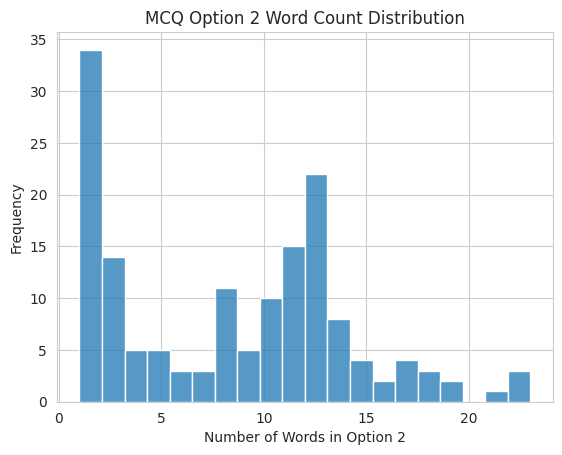

In [63]:
mcq_option_2_words_distrib = [len(sample.split()) for sample in mcq_options_2]
sns.set_style("whitegrid")
sns.histplot(mcq_option_2_words_distrib, bins=20)
plt.title(f'MCQ Option 2 Word Count Distribution')
plt.xlabel('Number of Words in Option 2')
plt.ylabel('Frequency')
plt.show()

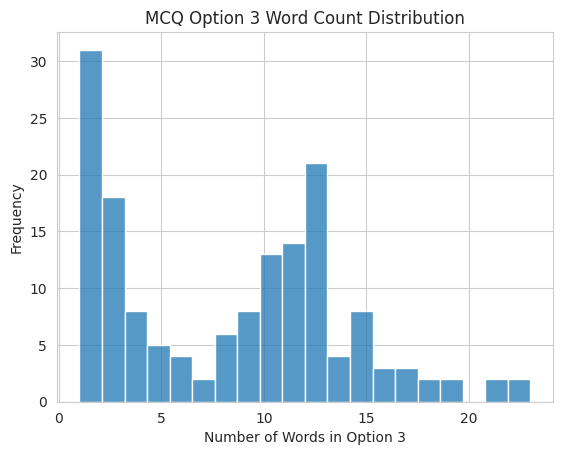

In [64]:
mcq_option_3_words_distrib = [len(sample.split()) for sample in mcq_options_3]
sns.set_style("whitegrid")
sns.histplot(mcq_option_3_words_distrib, bins=20)
plt.title(f'MCQ Option 3 Word Count Distribution')
plt.xlabel('Number of Words in Option 3')
plt.ylabel('Frequency')
plt.show()

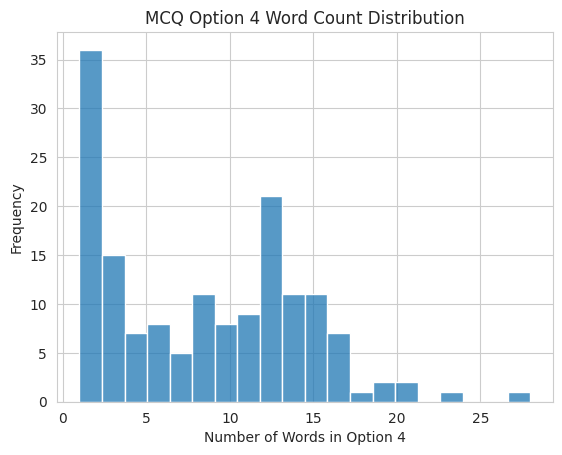

In [65]:
mcq_option_4_words_distrib = [len(sample.split()) for sample in mcq_options_4]
sns.set_style("whitegrid")
sns.histplot(mcq_option_4_words_distrib, bins=20)
plt.title(f'MCQ Option 4 Word Count Distribution')
plt.xlabel('Number of Words in Option 4')
plt.ylabel('Frequency')
plt.show()

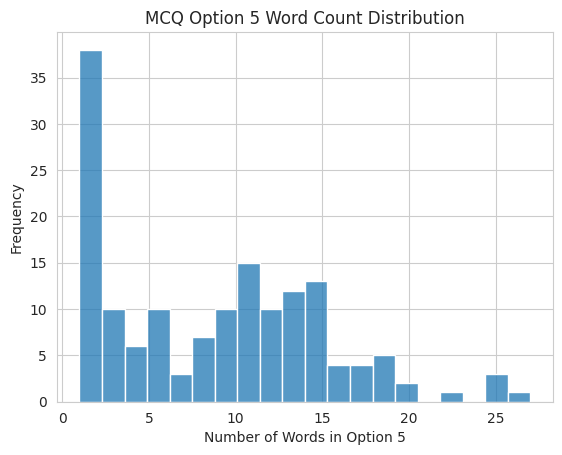

In [66]:
mcq_option_5_words_distrib = [len(sample.split()) for sample in mcq_options_5]
sns.set_style("whitegrid")
sns.histplot(mcq_option_5_words_distrib, bins=20)
plt.title(f'MCQ Option 5 Word Count Distribution')
plt.xlabel('Number of Words in Option 5')
plt.ylabel('Frequency')
plt.show()

#### Close-Ended Questions/Answers

In [15]:
print("Total Close-Ended Questions/Answers: ", len(vqa_data[(~vqa_data['Close-Ended Question 1'].isnull()) &
                                                    (~vqa_data['Close-Ended Answer 1'].isnull())]))

Total Close-Ended Questions/Answers:  157


In [67]:
close_ended_questions = list(vqa_data['Close-Ended Question 1'].dropna().unique())

valid_close_ended_questions = [sample for sample in close_ended_questions if len(sample.split()) >= 5]

print(f'Number of Valid Close-Ended Questions: {len(valid_close_ended_questions)}/{len(close_ended_questions)}')

close_ended_questions_first_word = [sample.split()[0].lower() for sample in valid_close_ended_questions]
counts = Counter(close_ended_questions_first_word)
print(f"First Word in Close-Ended Questions: ", counts)

Number of Valid Close-Ended Questions: 152/154
First Word in Close-Ended Questions:  Counter({'is': 60, 'does': 39, 'would': 15, 'are': 13, 'could': 5, 'do': 4, 'can': 3, 'the': 2, 'this': 2, 'considering': 2, 'increased': 1, 'one': 1, 'in': 1, 'if': 1, 'should': 1, 'assuming': 1, 'i': 1})


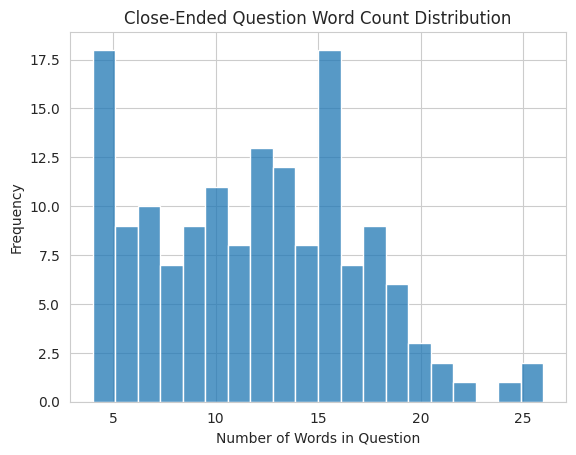

In [ ]:
close_ended_questions_words_distrib = [len(sample.split()) for sample in close_ended_questions]
sns.set_style("whitegrid")
sns.histplot(close_ended_questions_words_distrib, bins=20)
plt.title(f'Close-Ended Question Word Count Distribution')
plt.xlabel('Number of Words in Close-Ended Question')
plt.ylabel('Frequency')
plt.show()